In [70]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
plt.rcParams['animation.embed_limit'] = 600.0

In [76]:
import numpy as np
import matplotlib.pyplot as plt

def sign(t):
  if t>0:
    return 1
  if t == 0:
    return 0
  if t<0:
    return -1
  # Explicitly return a value even if t is NaN
  return np.nan # Or some other appropriate value like 0


def bungee_ode(t,y_vec):
  x=y_vec[0]
  v=y_vec[1]
  g=9.81
  L=30
  Cd,k,gamma,m=0.25,40,8,68.1
  if x<=L:
    dv_dt=g-(sign(v)*Cd*v**2)/m
  else:
    dv_dt=g-(sign(v)*Cd*v**2)/m-(k*(x-L))/m-(gamma*v)/m
  dx_dt=v
  return np.array([dx_dt,dv_dt])

def RK4(f,t0,y0,h,t1):
    t_history = [t0]
    y_history = [y0]
    error_at_t=[0]
    t = t0
    y = y0
    delta_new = 10**-3

    while t<t1:
      if t + h > t1:
            h = t1 - t

      K1=f(t,y)
      K2=f(t+h/5,y+h/5*K1)
      K3=f(t+3*h/10,y+3*h/40*K1+(9/40)*K2*h)
      K4=f(t+3*h/5,y+3*h*K1/10-9*K2*h/10+(6/5)*h*K3)
      K5=f(t+h,y-11*h*K1/54+5*K2*h/2-(70/27)*h*K3+35*K4*h/27)
      K6=f(t+7*h/8,y+1631*h*K1/55296+175*K2*h/512+(575/13824)*h*K3+44275*K4*h/110592+253*K5*h/4096)

      x4,v4=y+h*(37*K1/378+250*K3/621+125*K4/594+514*K6/1771)
      x5,v5=y+h*(2825*K1/27648+18575*K3/48384+13525*K4/55296+277*K5/14336+K6/4)
      delta_present=abs(v5-v4)

      if delta_present<=delta_new:

       h_new=h*abs((delta_new/delta_present)**(1/5))
       t += h
       y = x5,v5
       t_history.append(t)
       y_history.append(y)
       error_at_t.append(delta_present)
      else:

        h=h*abs((delta_new/delta_present)**(1/4))

    return np.array(t_history), np.array(y_history) ,np.array(error_at_t)

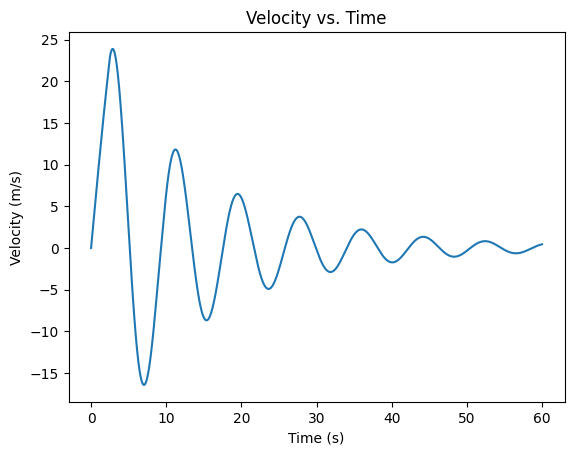

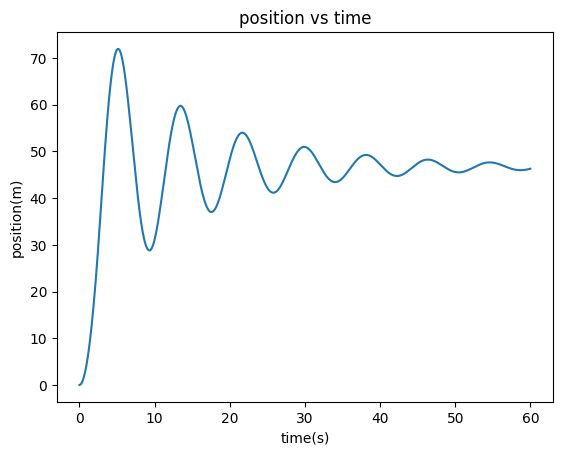

2755

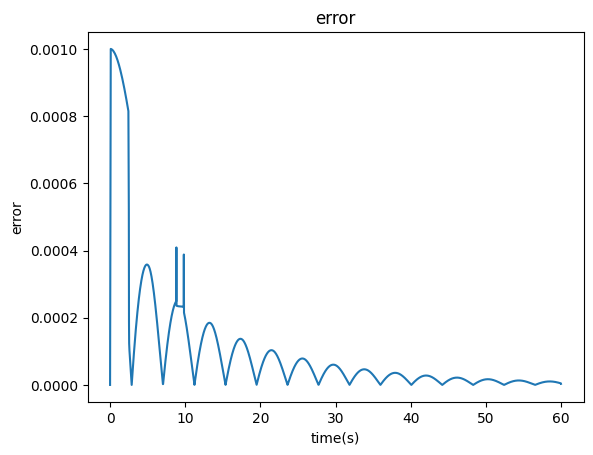

In [77]:
t, y,e = RK4(bungee_ode,0,np.array([0,0]),0.5,60)
velocity=y[:,1]
position=y[:,0]
plt.plot(t, velocity)
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.title("Velocity vs. Time")
plt.show()
plt.plot(t,position)
plt.xlabel("time(s)")
plt.ylabel("position(m)")
plt.title("position vs time")
plt.show()
plt.plot(t,e)
plt.xlabel("time(s)")
plt.ylabel("error")
plt.title("error")
t.size

Rendering animation...


KeyboardInterrupt: 

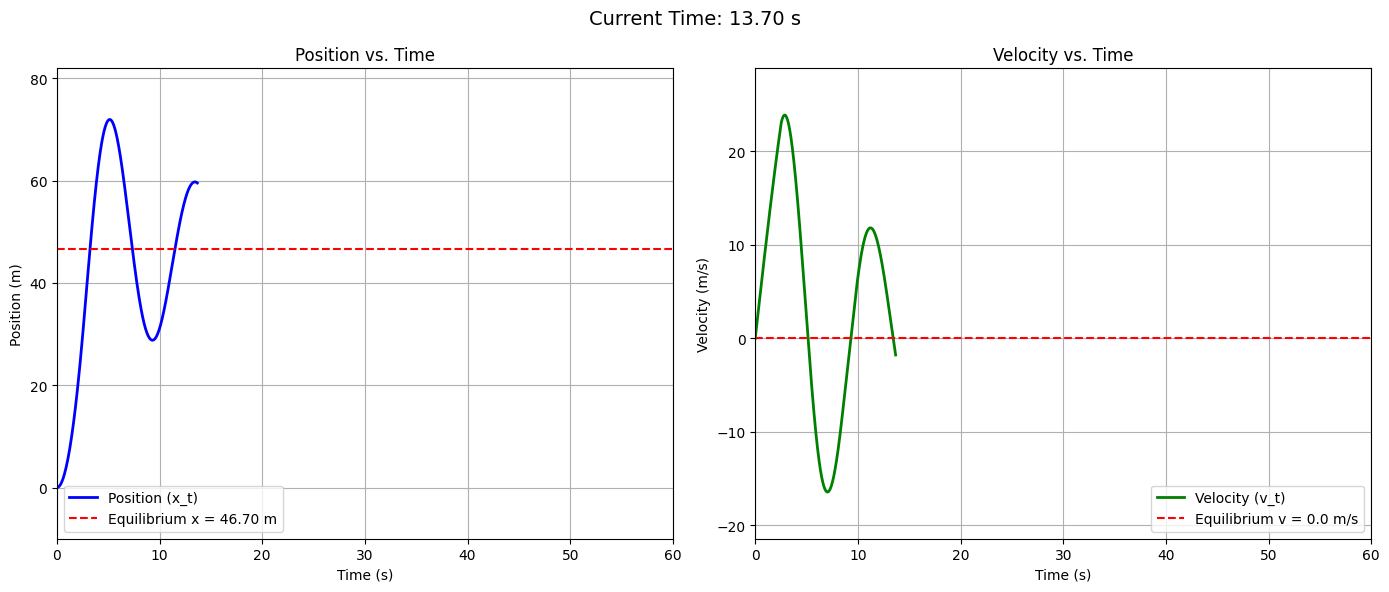

In [78]:
v_data = velocity
x_data = position
x_equi_val = (68.1 * 9.81 /40 ) + 30
t_start = 0
v_equi_val = 0
time_data = t
fig, (ax_pos, ax_vel) = plt.subplots(1, 2, figsize=(14, 6))

# Animated line objects
line_pos, = ax_pos.plot([], [], 'b-', lw=2, label='Position (x_t)')
line_vel, = ax_vel.plot([], [], 'g-', lw=2, label='Velocity (v_t)')

# Static equilibrium lines (using axhline for simplicity)
ax_pos.axhline(y=x_equi_val, color='r', linestyle='--', label=f'Equilibrium x = {x_equi_val:.2f} m')
ax_vel.axhline(y=v_equi_val, color='r', linestyle='--', label='Equilibrium v = 0.0 m/s')

# Set plot limits
ax_pos.set_xlim(t_start, 60)
ax_pos.set_ylim(min(x_data) - 10, max(x_data) + 10)
ax_pos.set_xlabel('Time (s)')
ax_pos.set_ylabel('Position (m)')
ax_pos.set_title('Position vs. Time')
ax_pos.legend()
ax_pos.grid(True)

ax_vel.set_xlim(t_start, 60)
ax_vel.set_ylim(min(v_data) - 5, max(v_data) + 5)
ax_vel.set_xlabel('Time (s)')
ax_vel.set_ylabel('Velocity (m/s)')
ax_vel.set_title('Velocity vs. Time')
ax_vel.legend()
ax_vel.grid(True)

fig.suptitle(f'Current Time: {t_start:.2f} s', fontsize=14)
plt.tight_layout()

pos_text = ax_pos.text(0.65, 0.9, '', transform=ax_pos.transAxes,
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)) # <-- NEW
vel_text = ax_vel.text(0.65, 0.9, '', transform=ax_vel.transAxes,
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)) # <-- NEW

# --- 7. Animation Functions ---
def init():
    line_pos.set_data([], [])
    line_vel.set_data([], [])
    return line_pos, line_vel,

def animate(i):
    # Update animated lines
    line_pos.set_data(time_data[:i], x_data[:i])
    line_vel.set_data(time_data[:i], v_data[:i])

    # Update time display
    fig.suptitle(f'Current Time: {time_data[i]:.2f} s', fontsize=14)

    return line_pos, line_vel,

# --- 8. Create and Display Animation ---
ani = animation.FuncAnimation(
    fig, animate, init_func=init, frames=len(time_data), interval=20, blit=True
)

# Display in Jupyter/Colab
print("Rendering animation...")
HTML(ani.to_jshtml())